# Computer Exercise 4.2 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 4.2 Errors in Polynomial Interpolation — *나눗셈차분의 적분표현과 Hermite 보간*
> **풀이 일자**: Day 104
> **언어**: Python 3 (NumPy · pandas · Matplotlib · SciPy · mpmath · fractions)

P1 은 $\lambda(x)=\dfrac{f(x)-p_n(x)}{\omega(x)}$ 가 절점에서 $0/0$ 이 되지만 극한은 존재한다는
것을 60 자리로 확인하고, 그 올바른 언어가 **나눗셈차분** $f[x_0,\dots,x_n,x]$ 라고 예고했다.
이 노트북은 그 연속성을 **증명하는 표현**을 수치로 확인하고, 그 연속성을 실제로 사용한다 —
절점을 **병합**해서 Hermite 보간을 얻는다.

## 1. 문제 (원문)

> **Computer Exercise 4.2.2.** (a) The divided difference has the integral (Hermite–Genocchi)
> representation
> $$f[x_0,x_1,\dots,x_n]=\int_{\Sigma_n} f^{(n)}\!\left(\sum_{i=0}^{n}t_ix_i\right)dt_1\cdots dt_n,
> \qquad \Sigma_n=\Big\{t_i\ge 0,\ \textstyle\sum_{i=0}^n t_i=1\Big\}.$$
> Verify this numerically for several $f$ and several $n$ by Monte-Carlo integration over the
> simplex, and confirm that the observed error decreases like $N^{-1/2}$.
> (b) Deduce from (a) that $f[x_0,\dots,x_n]$ is a **continuous** function of its arguments, so that
> letting all nodes coalesce gives $f[x,x,\dots,x]=f^{(n)}(x)/n!$. Verify this limit numerically and
> explain the behaviour of the computed value in floating point as the nodes coalesce.
> (c) Use confluent divided differences to implement **Hermite interpolation** (matching $f$ and
> $f'$ at each node) and verify the error formula
> $$f(x)-H_{2n+1}(x)=\frac{f^{(2n+2)}(\xi_x)}{(2n+2)!}\,\omega(x)^2 .$$
> (d) Compare Hermite interpolation at $n+1$ nodes with Lagrange interpolation at $2n+2$ nodes —
> both give a polynomial of degree $2n+1$ from $2n+2$ pieces of data. Which is more accurate, and
> why?

### 한국어 풀이용 정리

이 문제는 §4.2 의 **숨은 뼈대**를 다룬다. 오차식의 두 번째 형태

$$f(x)-p_n(x)=f[x_0,\dots,x_n,x]\,\omega(x)$$

는 $f$ 의 미분가능성을 **전혀 요구하지 않는다** (나눗셈차분은 순수 대수적 양이다). 반면 첫 번째
형태 $f^{(n+1)}(\xi_x)/(n+1)!$ 는 $C^{n+1}$ 을 요구한다. 두 형태가 같다는 것은
$f[x_0,\dots,x_n]=f^{(n)}(\xi)/n!$ 라는 **평균값 정리**이고, 그 정리의 가장 깨끗한 증명이
Hermite–Genocchi 적분표현이다 — 적분표현은 (i) 연속성, (ii) 평균값 정리, (iii) 중복절점으로의
확장을 **한꺼번에** 준다.

세 단계로 간다.

1. **적분표현을 믿을 수 있는가** — 단체 $\Sigma_n$ 위의 Monte-Carlo 로 직접 적분해 나눗셈차분과
   맞춰 본다. 정규화가 미묘하다: $\Sigma_n$ 의 부피가 $1/n!$ 이므로
   $\int_{\Sigma_n}g = \tfrac{1}{n!}\mathbb E_{\rm unif}[g]$.
2. **연속성이 무엇을 주는가** — 적분표현의 피적분함수는 절점에 대해 연속이므로 나눗셈차분도
   그렇다. 절점을 모두 한 점으로 보내면 $f[x,\dots,x]=f^{(n)}(x)/n!$. 이 극한을 float64 로
   추적하면 **U자 곡선**이 나온다 (절단오차 $O(\varepsilon_{\rm gap})$ 대 반올림
   $O(\epsilon/\varepsilon_{\rm gap}^{\,n})$). mpmath 로 하면 U자가 사라진다 — 즉 U자는
   수학이 아니라 산술의 성질이다.
3. **연속성을 사용한다** — 절점을 두 개씩 겹쳐 놓으면 나눗셈차분표가 그대로 **Hermite 보간**이
   된다. 오차식의 $\omega(x)^2$ 는 절점이 두 겹이라는 사실의 직접적 결과이고, 그 제곱은
   **오차의 부호를 고정**시킨다 ($f^{(2n+2)}>0$ 이면 $f-H$ 는 어디서도 부호를 바꾸지 않는다).

## 2. 수학적 배경

### 2.1 Hermite–Genocchi 적분표현

**정리.** $f\in C^{n}[a,b]$, $x_0,\dots,x_n\in[a,b]$ (중복 허용) 이면

$$\boxed{\;f[x_0,\dots,x_n]=\int_{\Sigma_n}f^{(n)}\!\Big(\sum_{i=0}^n t_ix_i\Big)\,dt,\qquad
\Sigma_n=\Big\{t\in\mathbb R^{n}_{\ge0}:\ \textstyle\sum_{i=1}^{n}t_i\le1\Big\},\ \ t_0=1-\sum_{i\ge1}t_i.\;}$$

*확인 (정규화).* $f(x)=x^n$ 이면 $f^{(n)}\equiv n!$ 이고 $|\Sigma_n|=1/n!$ 이므로 우변 $=1$.
좌변도 $x^n$ 의 $n$ 차 나눗셈차분 $=1$ (최고차 계수). ✓

*따름정리 1 (연속성).* 피적분함수가 $(x_0,\dots,x_n)$ 에 대해 연속이고 적분영역이 고정이므로
$f[x_0,\dots,x_n]$ 은 **모든 인수에 대해 연속**이다 — 절점이 서로 달라야 한다는 조건 없이.

*따름정리 2 (평균값 정리).* $\sum t_ix_i$ 는 $[\min x_i,\max x_i]$ 안에 있고 $|\Sigma_n|=1/n!$ 이므로
적분평균값 정리에서
$$f[x_0,\dots,x_n]=\frac{f^{(n)}(\xi)}{n!},\qquad \xi\in[\min x_i,\max x_i].$$
이것이 P1 의 $\xi_x$ 의 출처다: $\lambda(x)=f[x_0,\dots,x_n,x]=f^{(n+1)}(\xi_x)/(n+1)!$.

*따름정리 3 (중복절점).* 연속성으로 모든 $x_i\to x$ 를 보내면 $\sum t_ix_i\to x$ 이므로
$$\boxed{\;f[\underbrace{x,\dots,x}_{n+1}]=\frac{f^{(n)}(x)}{n!}.\;}$$

### 2.2 Hermite 보간

절점 $x_0,\dots,x_n$ 각각을 **두 번** 쓴 $2n+2$ 개의 목록
$z_0=z_1=x_0,\ z_2=z_3=x_1,\dots$ 에 대해 Newton 형식을 그대로 쓰면 차수 $\le 2n+1$ 의 다항식

$$H(x)=\sum_{k=0}^{2n+1} f[z_0,\dots,z_k]\prod_{j<k}(x-z_j)$$

를 얻고, 이것이 $H(x_i)=f(x_i)$, $H'(x_i)=f'(x_i)$ 를 만족하는 **유일한** 다항식이다.
표를 만들 때 대각 위치의 $0/0$ 은 따름정리 3 으로 $f[x_i,x_i]=f'(x_i)$ 로 채운다.

**오차식.** 절점이 두 겹이므로 P1 §2.1 의 Rolle 논증이 $\omega$ 대신 $\omega^2$ 로 반복되어

$$\boxed{\;f(x)-H(x)=\frac{f^{(2n+2)}(\xi_x)}{(2n+2)!}\;\omega(x)^2,\qquad
\omega(x)=\prod_{i=0}^n(x-x_i).\;}$$

$\omega^2\ge0$ 이므로 **$f^{(2n+2)}$ 가 부호를 유지하면 $f-H$ 도 부호를 유지한다** — Lagrange
보간에는 없는 성질이고, 수치적으로 확인하기 쉬운 강한 예측이다.

### 2.3 같은 자유도의 두 선택

$2n+2$ 개의 데이터로 차수 $2n+1$ 의 다항식을 만드는 두 방법:

| | 절점 수 | 쓰는 정보 | 오차 계수 |
|---|---|---|---|
| Hermite | $n+1$ | $f,f'$ | $\dfrac{f^{(2n+2)}(\xi)}{(2n+2)!}\,\omega_{n+1}(x)^2$ |
| Lagrange | $2n+2$ | $f$ 만 | $\dfrac{f^{(2n+2)}(\xi)}{(2n+2)!}\,\omega_{2n+2}(x)$ |

도함수 인자가 **같으므로** 비교는 $\|\omega_{n+1}^2\|_\infty$ 대 $\|\omega_{2n+2}\|_\infty$ 만
남는다. 이 비는 **구간에 무관**하다: 아핀 변환 $[-1,1]\to[a,b]$ 는 분자와 분모에 똑같이
$((b-a)/2)^{2n+2}$ 를 곱한다.

* **Chebyshev 배치**: Lagrange 는 $\|\omega_{2n+2}\|=2^{-(2n+1)}$, Hermite 는
  $\|\omega_{n+1}^2\|=(2^{-n})^2=2^{-2n}$ 이므로 비가 **정확히 2** — Lagrange 가 2 배 유리.
* **등간격 배치**: 자명하지 않다. Lagrange 는 절점을 $2n+2$ 개로 늘려 간격이 절반이 되는데,
  등간격 $\omega$ 의 끝 봉우리는 절점 수에 대해 매우 빠르게 커진다. 제곱의 불리함과 절점을
  두 배로 늘리는 불리함 중 어느 쪽이 큰지는 **재 봐야 안다** (셀 [5]).

## 3. 풀이 흐름

1. **나눗셈차분 구현** — float64 표, mpmath 고정밀 표, `fractions.Fraction` 정확산술 표.
   중복절점을 허용하도록 대각 채우기를 넣는다 (같은 코드가 Lagrange 와 Hermite 를 모두 처리).
2. **적분표현의 Monte-Carlo 검증** — Dirichlet$(1,\dots,1)$ 로 $\Sigma_n$ 을 균등표본하고
   $\tfrac1{n!}\mathbb E[f^{(n)}(t\cdot x)]$ 를 나눗셈차분과 비교. $f=e^{x}$, $1/(1+x)$,
   $n=1,\dots,6$, $N$ 을 키우며 오차가 $N^{-1/2}$ 로 줄어드는지 회귀로 확인.
   $n=1,2$ 는 `scipy.integrate` 로 결정적 적분도 해서 MC 와 무관하게 못 박는다.
3. **병합 극한** — $x_i=x_0+i\,h$ 로 두고 $h\to0$. float64 · mpmath 두 산술로 같은 곡선을 그려
   U 자가 산술의 성질임을 보인다. 최적 $h^\star\approx(\epsilon)^{1/(n+1)}$ 예측과 실측 대조.
4. **Hermite 보간** — 위 표를 두겹 절점에 적용. $H(x_i),H'(x_i)$ 일치 검증, 오차식의 $\xi_x$
   역산 ($f=e^{x}$), **부호 불변성** 검증.
5. **Hermite vs Lagrange** — 같은 차수 $2n+1$ 에서 $e^{x}$ (매끄러움) 와 Runge (특이점 근접) 를
   등간격·Chebyshev 두 배치로. §2.3 의 "정확히 2 배" 예측 검증.
6. **시각화** — (a) MC 수렴, (b) 병합 U 자, (c) 두 보간의 오차 곡선, (d) Hermite 오차/$\omega^2$.
7. **해석**.

In [1]:
# ══════════════════════════════════════════════════════════════════════════
# [1]  나눗셈차분 —  float64 / mpmath / Fraction,  중복절점 허용
# ══════════════════════════════════════════════════════════════════════════
import numpy as np, pandas as pd, matplotlib
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import mpmath as mp
from fractions import Fraction
from math import factorial
from scipy import integrate

mp.mp.dps = 50
pd.set_option("display.float_format", lambda v: f"{v:.6g}")
rng = np.random.default_rng(104002)

def divided_differences(z, fvals, dvals=None, one=1.0):
    """
    Newton 계수 c[k] = f[z_0..z_k].
    z 는 중복 가능.  중복 블록에서는 fvals 대신 도함수를 쓴다:
        f[z_i..z_{i+m}] = f^{(m)}(z_i)/m!      (모두 같은 점일 때)
    dvals[m][i] = f^{(m)}(z_i)  (m=0..최대중복도).  중복이 없으면 None 이어도 된다.
    """
    n = len(z)
    T = [[None]*(n-k) for k in range(n)]
    T[0] = list(fvals)
    for k in range(1, n):
        for i in range(n-k):
            if z[i+k] == z[i]:                       # 완전 중복 블록
                T[k][i] = dvals[k][i]/factorial(k)
            else:
                T[k][i] = (T[k-1][i+1] - T[k-1][i])/(z[i+k]-z[i])
    return [T[k][0] for k in range(n)]

def newton_eval(z, coef, x):
    """중첩곱 (Horner) 평가."""
    s = coef[-1]
    for k in range(len(coef)-2, -1, -1):
        s = s*(x - z[k]) + coef[k]
    return s

def newton_eval_np(z, coef, xq):
    xq = np.asarray(xq, float); s = np.full_like(xq, float(coef[-1]))
    for k in range(len(coef)-2, -1, -1):
        s = s*(xq - z[k]) + coef[k]
    return s

# ---------- 시험 함수 (n 계 도함수가 닫힌 형태) ----------
FN = {
 "exp(x)": dict(f=np.exp, d=lambda m, x: np.exp(x),
                fmp=mp.exp, dmp=lambda m, x: mp.exp(x),
                fq =lambda q: None),
 "1/(1+x)": dict(f=lambda x: 1/(1+x),
                 d=lambda m, x: (-1)**m*factorial(m)/(1+x)**(m+1),
                 fmp=lambda x: 1/(1+x),
                 dmp=lambda m, x: (-1)**m*mp.factorial(m)/(1+x)**(m+1),
                 fq =lambda q: Fraction(1,1)/(1+q)),
}

NODES = [Fraction(0), Fraction(3,10), Fraction(1,2), Fraction(9,10),
         Fraction(6,5), Fraction(17,10), Fraction(21,10)]
print("절점:", [float(t) for t in NODES])

# 정확산술 참값 (1/(1+x) 는 유리수)
zq = list(NODES); fq = [FN["1/(1+x)"]["fq"](t) for t in zq]
cq = divided_differences(zq, fq, one=Fraction(1))
print("\n[a]  1/(1+x) 의 나눗셈차분 —  Fraction 정확산술 vs float64")
zf = [float(t) for t in NODES]
cf = divided_differences(zf, [1/(1+t) for t in zf])
df1 = pd.DataFrame(dict(k=range(len(cq)),
                        exact=[float(v) for v in cq], float64=cf,
                        rel_err=[abs(float(a)-b)/abs(float(a)) for a, b in zip(cq, cf)]))
print(df1.to_string(index=False))
print("  최대 상대오차:", f"{df1.rel_err.max():.3e}   (절점이 잘 떨어져 있어 소거가 없다)")


절점: [0.0, 0.3, 0.5, 0.9, 1.2, 1.7, 2.1]

[a]  1/(1+x) 의 나눗셈차분 —  Fraction 정확산술 vs float64
 k      exact    float64     rel_err
 0          1          1           0
 1  -0.769231  -0.769231 2.88658e-16
 2   0.512821   0.512821 1.73195e-15
 3  -0.269906  -0.269906 4.73038e-15
 4   0.122684   0.122684 1.06331e-14
 5 -0.0454386 -0.0454386 1.93941e-14
 6  0.0146576  0.0146576 3.29012e-14
  최대 상대오차: 3.290e-14   (절점이 잘 떨어져 있어 소거가 없다)


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# [2]  Hermite–Genocchi 적분표현의 Monte-Carlo 검증
# ══════════════════════════════════════════════════════════════════════════
#   f[x_0..x_n] = ∫_{Σ_n} f^{(n)}(Σ t_i x_i) dt ,   |Σ_n| = 1/n!
#              = (1/n!) · E_{t ~ Unif(Σ_n)} [ f^{(n)}(Σ t_i x_i) ]
def mc_genocchi(name, xs, N, rng):
    spec = FN[name]; n = len(xs)-1
    T = rng.dirichlet(np.ones(n+1), size=N)          # Σ_n 위의 균등분포
    vals = spec["d"](n, T @ np.asarray(xs, float))
    return vals.mean()/factorial(n), vals.std(ddof=1)/np.sqrt(N)/factorial(n)

def exact_dd(name, xs):
    return divided_differences(list(xs), [FN[name]["f"](x) for x in xs])[-1]

REPS = 16
rows, zrows = [], []
for name in FN:
    for n in (1, 2, 4, 6):
        xs = [float(t) for t in NODES[:n+1]]
        exact = exact_dd(name, xs)
        for N in (10**3, 10**4, 10**5):
            errs = []
            for _ in range(REPS):
                est, se = mc_genocchi(name, xs, N, rng)
                errs.append(abs(est-exact)/abs(exact))
            rows.append(dict(f=name, n=n, N=N,
                             rms_rel_err=float(np.sqrt(np.mean(np.square(errs))))))
        est, se = mc_genocchi(name, xs, 10**6, rng)     # 단일 장기 실행의 z 점수
        zrows.append(dict(f=name, n=n, exact=exact, mc=est, se=se,
                          z=(est-exact)/se))
df2 = pd.DataFrame(rows); dfz = pd.DataFrame(zrows)

print(f"[b]  적분표현의 MC 검증 —  독립 반복 {REPS} 회의 RMS 상대오차")
piv = df2.pivot_table(index=["f","n"], columns="N", values="rms_rel_err")
print(piv.to_string(float_format=lambda v: f"{v:.3e}"))
print("\n  N 을 100 배 키울 때의 RMS 오차비  (이론 1/10 = 0.1):")
print((piv[10**5]/piv[10**3]).to_string(float_format=lambda v: f"{v:.4f}"))
slopes = (df2.groupby(["f","n"])
            .apply(lambda g: np.polyfit(np.log10(g.N), np.log10(g.rms_rel_err), 1)[0],
                   include_groups=False))
print("\n  (f, n) 별 log-log 기울기  (이론 -0.5):")
print(slopes.to_string(float_format=lambda v: f"{v:+.4f}"))
print(f"  평균 {slopes.mean():+.4f},  표준편차 {slopes.std():.4f}")

print("\n  N = 10^6 단일 실행의 z 점수  z = (추정 - 참값)/표준오차   (|z| <~ 2 이면 정상):")
print(dfz.to_string(index=False, float_format=lambda v: f"{v:.6g}"))
print(f"  max|z| = {dfz.z.abs().max():.3f}   → 편향 없음.  MC 는 참값 주위에서 흔들릴 뿐이다.")

# ---------- 결정론적 확인 (MC 와 무관) ----------
print("\n[c]  n = 1, 2 는 결정론적 적분으로도 못 박는다")
rows = []
for name in FN:
    spec = FN[name]
    x0, x1, x2 = 0.0, 0.3, 0.5
    I1, _ = integrate.quad(lambda t: spec["d"](1, (1-t)*x0 + t*x1), 0, 1,
                           epsabs=1e-13, epsrel=1e-13)
    e1 = exact_dd(name, [x0, x1])
    I2, _ = integrate.dblquad(
        lambda t2, t1: spec["d"](2, (1-t1-t2)*x0 + t1*x1 + t2*x2),
        0, 1, lambda t1: 0, lambda t1: 1-t1, epsabs=1e-13, epsrel=1e-13)
    e2 = exact_dd(name, [x0, x1, x2])
    rows += [dict(f=name, n=1, quad=I1, divdiff=e1, abs_diff=abs(I1-e1)),
             dict(f=name, n=2, quad=I2, divdiff=e2, abs_diff=abs(I2-e2))]
print(pd.DataFrame(rows).to_string(index=False))


[b]  적분표현의 MC 검증 —  독립 반복 16 회의 RMS 상대오차
N            1000      10000     100000
f       n                              
1/(1+x) 1 3.816e-03 1.256e-03 5.710e-04
        2 1.025e-02 2.737e-03 6.098e-04
        4 2.064e-02 5.766e-03 2.036e-03
        6 3.227e-02 8.553e-03 3.002e-03
exp(x)  1 3.548e-03 7.056e-04 3.042e-04
        2 2.303e-03 1.404e-03 2.689e-04
        4 5.983e-03 1.805e-03 6.027e-04
        6 9.184e-03 2.464e-03 1.247e-03

  N 을 100 배 키울 때의 RMS 오차비  (이론 1/10 = 0.1):
f        n
1/(1+x)  1   0.1496
         2   0.0595
         4   0.0986
         6   0.0930
exp(x)   1   0.0857
         2   0.1168
         4   0.1007
         6   0.1358

  (f, n) 별 log-log 기울기  (이론 -0.5):
f        n
1/(1+x)  1   -0.4125
         2   -0.6128
         4   -0.5030
         6   -0.5157
exp(x)   1   -0.5335
         2   -0.4663
         4   -0.4984
         6   -0.4335
  평균 -0.4970,  표준편차 0.0624

  N = 10^6 단일 실행의 z 점수  z = (추정 - 참값)/표준오차   (|z| <~ 2 이면 정상):
      f  n      exact         mc     

In [3]:
# ══════════════════════════════════════════════════════════════════════════
# [3]  절점 병합 —  f[x,..,x] = f^{(n)}(x)/n!  와 그 부동소수점 U 자
# ══════════════════════════════════════════════════════════════════════════
x0 = 0.4
hs = np.array([10.0**(-k) for k in np.arange(0.5, 6.01, 0.25)])

def merged_dd_float(name, n, h):
    xs = [x0 + i*h for i in range(n+1)]
    return divided_differences(xs, [FN[name]["f"](x) for x in xs])[-1]

def merged_dd_mp(name, n, h, dps=60):
    old = mp.mp.dps; mp.mp.dps = dps
    xs = [mp.mpf(x0) + i*mp.mpf(h) for i in range(n+1)]
    c  = divided_differences(xs, [FN[name]["fmp"](x) for x in xs])[-1]
    mp.mp.dps = old
    return c

rows = []
for name in ("exp(x)", "1/(1+x)"):
    for n in (3, 5):
        truth = FN[name]["d"](n, x0)/factorial(n)
        for h in hs:
            e_f = abs(merged_dd_float(name, n, h) - truth)/abs(truth)
            e_m = abs(float(merged_dd_mp(name, n, h)) - truth)/abs(truth)
            rows.append(dict(f=name, n=n, h=h, rel_float64=e_f, rel_mp60=e_m))
df3 = pd.DataFrame(rows)
print("[d]  x_i = 0.4 + i·h  의 최고차 나눗셈차분이 f^{(n)}(0.4)/n! 로 가는가")
show = df3[(df3.f=="exp(x)") & (df3.n==5)]
print(show[["h","rel_float64","rel_mp60"]].to_string(index=False,
        float_format=lambda v: f"{v:.3e}"))

print("\n  산술별 최소 달성 오차와 그때의 h:")
for (name, n), g in df3.groupby(["f","n"]):
    i_f = g.rel_float64.idxmin(); i_m = g.rel_mp60.idxmin()
    h_opt_theory = (np.finfo(float).eps)**(1.0/(n+1))
    print(f"   {name:9s} n={n}:  float64  h*={g.loc[i_f,'h']:.3e}"
          f"  err={g.loc[i_f,'rel_float64']:.3e}   |  이론 h* = eps^(1/(n+1)) = {h_opt_theory:.3e}"
          f"   |  mp60: h=1e-6 에서 err={g.rel_mp60.min():.3e} (감소 계속)")
print("\n  → float64 곡선은 U 자, mpmath 곡선은 단조 감소.")
print("    U 자의 오른쪽 가지는 절단오차 O(h), 왼쪽 가지는 소거 O(eps/h^n).")
print("    극한 f[x,..,x]=f^{(n)}(x)/n! 는 수학적 사실이고, U 자는 산술의 사실이다.")

# 완전 중복을 코드에 직접 넣어 확인 (h = 0)
print("\n[e]  h = 0 (완전 중복) 을 divided_differences 에 직접 넣기")
for name in ("exp(x)", "1/(1+x)"):
    for n in (3, 5):
        z = [x0]*(n+1)
        dv = {m: [FN[name]["d"](m, x0)]*(n+1) for m in range(n+1)}
        c  = divided_differences(z, [FN[name]["f"](x0)]*(n+1), dvals=dv)
        truth = FN[name]["d"](n, x0)/factorial(n)
        print(f"   {name:9s} n={n}:  f[x,..,x] = {c[-1]:.12g}   f^(n)(x)/n! = {truth:.12g}"
              f"   rel = {abs(c[-1]-truth)/abs(truth):.2e}")


[d]  x_i = 0.4 + i·h  의 최고차 나눗셈차분이 f^{(n)}(0.4)/n! 로 가는가
        h  rel_float64  rel_mp60
3.162e-01    1.251e+00 1.251e+00
1.778e-01    5.701e-01 5.701e-01
1.000e-01    2.867e-01 2.867e-01
5.623e-02    1.517e-01 1.517e-01
3.162e-02    8.249e-02 8.249e-02
1.778e-02    4.553e-02 4.553e-02
1.000e-02    2.534e-02 2.534e-02
5.623e-03    1.436e-02 1.416e-02
3.162e-03    8.188e-03 7.939e-03
1.778e-03    1.178e-02 4.456e-03
1.000e-03    1.233e+00 2.503e-03
5.623e-04    1.619e+01 1.407e-03
3.162e-04    9.383e+01 7.909e-04
1.778e-04    1.476e+03 4.447e-04
1.000e-04    7.088e+04 2.500e-04
5.623e-05    2.647e+05 1.406e-04
3.162e-05    4.707e+06 7.906e-05
1.778e-05    1.688e+08 4.446e-05
1.000e-05    1.226e+10 2.500e-05
5.623e-06    1.193e+11 1.406e-05
3.162e-06    2.824e+12 7.906e-06
1.778e-06    4.284e+13 4.446e-06
1.000e-06    1.039e+15 2.500e-06

  산술별 최소 달성 오차와 그때의 h:
   1/(1+x)   n=3:  float64  h*=5.623e-05  err=1.345e-04   |  이론 h* = eps^(1/(n+1)) = 1.221e-04   |  mp60: h=1e-6 에서 err=4.286e-

In [4]:
# ══════════════════════════════════════════════════════════════════════════
# [4]  Hermite 보간 —  구성 · 검증 · 오차식의 xi 역산 · 부호 불변성
# ══════════════════════════════════════════════════════════════════════════
def hermite(xs, f, df):
    """각 절점에서 f, f' 을 맞추는 차수 2n+1 의 Newton 형식 (z, coef) 반환."""
    z, fv, d1 = [], [], []
    for x in xs:
        z += [x, x]; fv += [f(x), f(x)]; d1 += [df(x), df(x)]
    dv = {1: d1}
    return z, divided_differences(z, fv, dvals=dv)

def omega_np(xs, xq):
    xq = np.atleast_1d(np.asarray(xq, float)); w = np.ones_like(xq)
    for t in xs: w *= (xq - t)
    return w

xs_h = np.linspace(0.0, 1.0, 5)                # n = 4  ->  차수 9
zH, cH = hermite(xs_h, np.exp, np.exp)

# (1) 보간 조건
hv  = newton_eval_np(zH, cH, xs_h)
eps = 1e-7
hd  = (newton_eval_np(zH, cH, xs_h+eps) - newton_eval_np(zH, cH, xs_h-eps))/(2*eps)
print("[f]  Hermite 보간 조건의 검증  (f = e^x, 절점 5 개, 차수 9)")
print(pd.DataFrame(dict(x=xs_h, f=np.exp(xs_h), H=hv, err_val=np.abs(hv-np.exp(xs_h)),
                        fprime=np.exp(xs_h), Hprime=hd,
                        err_der=np.abs(hd-np.exp(xs_h)))).to_string(index=False))
print("  (H' 는 중심차분으로 재서 O(eps^2) 오차가 남는다 — 값 쪽만 기계정밀도.)")

# (2) 오차식의 xi 역산 —  E 와 omega^2 가 둘 다 작으므로 반드시 고정밀로 (P1 의 교훈)
mp.mp.dps = 50
xs_mp = [mp.mpf(t) for t in xs_h]
zHm, cHm = hermite(xs_mp, mp.exp, mp.exp)
dense = np.linspace(0.0, 1.0, 601)
dense = dense[np.min(np.abs(dense[:,None]-xs_h[None,:]), axis=1) > 1e-6]
deg   = len(xs_h)*2                                   # 2n+2
E_mp, xi = [], []
for x in dense:
    xm = mp.mpf(float(x))
    e  = mp.exp(xm) - newton_eval(zHm, cHm, xm)
    w2 = mp.mpf(1)
    for t in xs_mp: w2 *= (xm - t)
    w2 = w2**2
    E_mp.append(e); xi.append(float(mp.log(mp.factorial(deg)*e/w2)))
E  = np.array([float(v) for v in E_mp]); xi = np.array(xi)
mp.mp.dps = 50
print(f"\n[g]  오차식 f - H = f^(2n+2)(xi)/(2n+2)! * omega^2   (2n+2 = {deg}, mpmath 50 자리)")
print(f"   E 의 부호:  양수 {int((E>0).sum())} 점,  음수 {int((E<0).sum())} 점"
      f"   ->  부호 불변성 {'성립' if (E>0).all() or (E<0).all() else '깨짐'}")
print(f"   |E| 의 범위: [{np.abs(E).min():.3e}, {np.abs(E).max():.3e}]"
      f"   (float64 로는 잴 수 없는 크기)")
print(f"   역산된 xi 의 범위: [{xi.min():.6f}, {xi.max():.6f}]   (구간 [0,1] 안:"
      f" {bool((xi>0).all() and (xi<1).all())})")
q = np.quantile(xi, [0, .25, .5, .75, 1])
print("   xi 의 5분위:", "  ".join(f"{v:.5f}" for v in q))

# (3) Lagrange 와의 부호 대비
zL  = [mp.mpf(t) for t in np.linspace(0.0, 1.0, 10)]
cL  = divided_differences(zL, [mp.exp(t) for t in zL])
EL  = np.array([float(mp.exp(mp.mpf(float(x))) - newton_eval(zL, cL, mp.mpf(float(x))))
                for x in dense])
sign_changes = int(np.sum(np.diff(np.sign(EL)) != 0))
print(f"\n   같은 차수 9 의 Lagrange 보간 (절점 10 개) 오차의 부호변화 횟수: {sign_changes}")
print(f"   Hermite 오차의 부호변화 횟수: {int(np.sum(np.diff(np.sign(E)) != 0))}")
print("   → omega^2 >= 0 이 부호를 고정한다.  Lagrange 는 절점마다 부호가 바뀐다.")


[f]  Hermite 보간 조건의 검증  (f = e^x, 절점 5 개, 차수 9)
   x       f       H  err_val  fprime  Hprime     err_der
   0       1       1        0       1       1 5.26356e-10
0.25 1.28403 1.28403        0 1.28403 1.28403  4.1541e-10
 0.5 1.64872 1.64872        0 1.64872 1.64872 8.05818e-11
0.75   2.117   2.117        0   2.117   2.117 1.32342e-09
   1 2.71828 2.71828        0 2.71828 2.71828 2.27903e-09
  (H' 는 중심차분으로 재서 O(eps^2) 오차가 남는다 — 값 쪽만 기계정밀도.)

[g]  오차식 f - H = f^(2n+2)(xi)/(2n+2)! * omega^2   (2n+2 = 10, mpmath 50 자리)
   E 의 부호:  양수 596 점,  음수 0 점   ->  부호 불변성 성립
   |E| 의 범위: [3.095e-16, 5.963e-12]   (float64 로는 잴 수 없는 크기)
   역산된 xi 의 범위: [0.460301, 0.550877]   (구간 [0,1] 안: True)
   xi 의 5분위: 0.46030  0.48231  0.50473  0.52759  0.55088

   같은 차수 9 의 Lagrange 보간 (절점 10 개) 오차의 부호변화 횟수: 8
   Hermite 오차의 부호변화 횟수: 0
   → omega^2 >= 0 이 부호를 고정한다.  Lagrange 는 절점마다 부호가 바뀐다.


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# [5]  같은 자유도:  Hermite (n+1 절점) vs Lagrange (2n+2 절점)
# ══════════════════════════════════════════════════════════════════════════
def cheb_nodes(m, a=-1.0, b=1.0):
    k = np.arange(m)
    return np.sort((a+b)/2 + (b-a)/2*np.cos((2*k+1)*np.pi/(2*m)))

CASES = {
  # exp 는 오차가 1e-30 아래로 내려가므로 mpmath 로 재야 한다 (P1 [g] 의 교훈)
  "exp on [0,1]":    dict(f=np.exp, df=np.exp, a=0.0, b=1.0, mp=True,
                          fmp=mp.exp, dfmp=mp.exp),
  "Runge on [-1,1]": dict(f=lambda x: 1/(1+25*x**2),
                          df=lambda x: -50*x/(1+25*x**2)**2, a=-1.0, b=1.0, mp=False),
}

def max_err_mp(xnodes, fmp, dfmp, grid, hermite_mode):
    old = mp.mp.dps; mp.mp.dps = 60
    zn = [mp.mpf(float(t)) for t in xnodes]
    if hermite_mode:
        z, c = hermite(zn, fmp, dfmp)
    else:
        z, c = zn, divided_differences(zn, [fmp(t) for t in zn])
    m = max(abs(fmp(mp.mpf(float(g))) - newton_eval(z, c, mp.mpf(float(g)))) for g in grid)
    mp.mp.dps = old
    return float(m)

rows = []
for cname, cs in CASES.items():
    grid_f = np.linspace(cs["a"], cs["b"], 8001)
    grid_m = np.linspace(cs["a"], cs["b"], 401)
    if not cs["mp"]: fg = cs["f"](grid_f)
    for fam in ("equispaced", "Chebyshev"):
        for n in (2, 3, 4, 5, 6, 8, 10):
            if fam == "equispaced":
                xh = np.linspace(cs["a"], cs["b"], n+1)
                xl = np.linspace(cs["a"], cs["b"], 2*n+2)
            else:
                xh = cheb_nodes(n+1, cs["a"], cs["b"])
                xl = cheb_nodes(2*n+2, cs["a"], cs["b"])
            if cs["mp"]:
                eH = max_err_mp(xh, cs["fmp"], cs["dfmp"], grid_m, True)
                eL = max_err_mp(xl, cs["fmp"], cs["dfmp"], grid_m, False)
            else:
                zH_, cH_ = hermite(xh, cs["f"], cs["df"])
                eH = np.max(np.abs(fg - newton_eval_np(zH_, cH_, grid_f)))
                cL_ = divided_differences(list(xl), [cs["f"](t) for t in xl])
                eL = np.max(np.abs(fg - newton_eval_np(list(xl), cL_, grid_f)))
            wH = np.max(omega_np(xh, grid_f)**2)
            wL = np.max(np.abs(omega_np(xl, grid_f)))
            rows.append(dict(case=cname, nodes=fam, n=n, degree=2*n+1,
                             err_Hermite=eH, err_Lagrange=eL, ratio_H_over_L=eH/eL,
                             w2_Hermite=wH, w_Lagrange=wL, w_ratio=wH/wL))
df5 = pd.DataFrame(rows)

print("[h]  같은 차수 2n+1 에서의 최대오차 비  Hermite / Lagrange")
print("     (exp 은 mpmath 60 자리,  Runge 는 float64 — 오차 크기가 O(1) 이므로)")
print(df5.pivot_table(index=["case","n"], columns="nodes", values="ratio_H_over_L")
        .to_string(float_format=lambda v: f"{v:.4g}"))

print("\n  절점다항식만의 비  ||omega_H^2||_inf / ||omega_L||_inf")
pw = df5.pivot_table(index="n", columns="nodes", values="w_ratio")
print(pw.to_string(float_format=lambda v: f"{v:.5g}"))
print("  * 이 비는 구간 [a,b] 에 무관하다: 아핀 변환이 분자·분모에 똑같이 ((b-a)/2)^{2n+2} 를")
print("    곱하므로 상쇄된다 — 그래서 두 CASE 에서 같은 값이 나온다.")
print(f"\n  Chebyshev 열의 값: 모든 n 에서 {df5[df5.nodes=='Chebyshev'].w_ratio.min():.6f}"
      f" ~ {df5[df5.nodes=='Chebyshev'].w_ratio.max():.6f}   (§2.3 의 예측: 정확히 2)")
print("    (2^{-n})^2 = 2^{-2n}  대  2^{-(2n+1)}  ->  비 = 2. ✓")

print("\n[i]  등간격에서는 예측이 뒤집힌다 —  w_ratio 가 n>=5 에서 1 아래로 내려간다")
sub = df5[df5.nodes=="equispaced"][["case","n","w_ratio","err_Hermite",
                                    "err_Lagrange","ratio_H_over_L"]]
print(sub.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
print("\n  이유: Lagrange 쪽은 절점을 2n+2 개로 늘리므로 간격이 절반이 되고, 등간격 omega 의")
print("  끝 봉우리는 절점 수에 대해 훨씬 빠르게 커진다.  Hermite 쪽은 절점이 n+1 개뿐이라")
print("  omega 가 훨씬 온순하고, 그것을 제곱해도 여전히 더 작다.")


[h]  같은 차수 2n+1 에서의 최대오차 비  Hermite / Lagrange
     (exp 은 mpmath 60 자리,  Runge 는 float64 — 오차 크기가 O(1) 이므로)
nodes               Chebyshev  equispaced
case            n                        
Runge on [-1,1] 2      0.8702       1.242
                3       1.437       2.021
                4      0.9927      0.7445
                5       1.691       0.401
                6       1.149      0.3739
                8       1.296      0.2708
                10      1.422      0.2179
exp on [0,1]    2           2       2.101
                3           2       1.361
                4           2       1.017
                5           2      0.8202
                6           2      0.6915
                8           2      0.5331
                10          2      0.4398

  절점다항식만의 비  ||omega_H^2||_inf / ||omega_L||_inf
nodes  Chebyshev  equispaced
n                           
2              2      2.1401
3              2      1.3716
4              2      1.0221
5              2     0.8

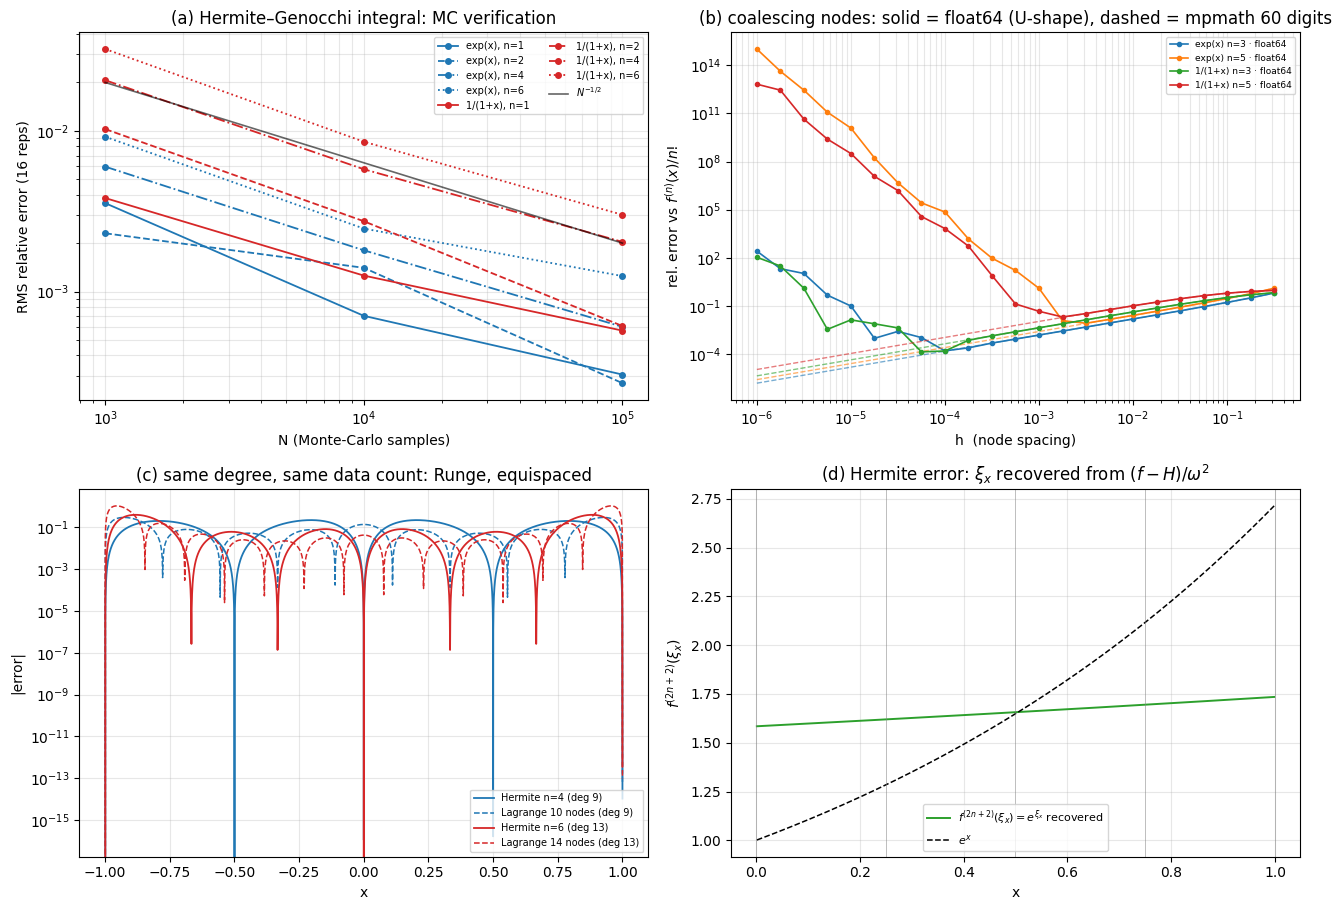

In [6]:
# ══════════════════════════════════════════════════════════════════════════
# [6]  시각화
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(2, 2, figsize=(13.2, 9.2))

# (a) MC 수렴
axA = ax[0,0]
for name, col in zip(FN, ("#1f77b4", "#d62728")):
    for n, ls in zip((1, 2, 4, 6), ("-", "--", "-.", ":")):
        g = df2[(df2.f==name)&(df2.n==n)].sort_values("N")
        axA.loglog(g.N, g.rms_rel_err, ls, marker="o", ms=4, color=col, lw=1.3,
                   label=f"{name}, n={n}")
Ns = np.array([1e3, 1e5])
axA.loglog(Ns, 2e-2*(Ns/1e3)**-0.5, "k-", lw=1.2, alpha=.6, label=r"$N^{-1/2}$")
axA.set_xlabel("N (Monte-Carlo samples)"); axA.set_ylabel("RMS relative error (16 reps)")
axA.set_title("(a) Hermite–Genocchi integral: MC verification")
axA.legend(fontsize=7, ncol=2); axA.grid(alpha=.3, which="both")

# (b) 병합 U 자
axB = ax[0,1]
for (name, n), col in zip([("exp(x)",3),("exp(x)",5),("1/(1+x)",3),("1/(1+x)",5)],
                          ("#1f77b4","#ff7f0e","#2ca02c","#d62728")):
    g = df3[(df3.f==name)&(df3.n==n)].sort_values("h")
    axB.loglog(g.h, np.maximum(g.rel_float64, 1e-20), "o-", ms=3, color=col, lw=1.2,
               label=f"{name} n={n} · float64")
    axB.loglog(g.h, np.maximum(g.rel_mp60, 1e-20), "--", color=col, lw=1.0, alpha=.6)
axB.set_xlabel("h  (node spacing)"); axB.set_ylabel(r"rel. error vs $f^{(n)}(x)/n!$")
axB.set_title("(b) coalescing nodes: solid = float64 (U-shape), dashed = mpmath 60 digits")
axB.legend(fontsize=6.5); axB.grid(alpha=.3, which="both")

# (c) 두 보간의 오차 곡선 (Runge, 등간격, n=6)
axC = ax[1,0]
cs = CASES["Runge on [-1,1]"]; g = np.linspace(-1, 1, 4001)
for n, col in zip((4, 6), ("#1f77b4", "#d62728")):
    xh = np.linspace(-1, 1, n+1); xl = np.linspace(-1, 1, 2*n+2)
    zH_, cH_ = hermite(xh, cs["f"], cs["df"])
    cL_ = divided_differences(list(xl), [cs["f"](t) for t in xl])
    axC.semilogy(g, np.abs(cs["f"](g) - newton_eval_np(zH_, cH_, g)),
                 color=col, lw=1.3, label=f"Hermite n={n} (deg {2*n+1})")
    axC.semilogy(g, np.abs(cs["f"](g) - newton_eval_np(list(xl), cL_, g)),
                 color=col, lw=1.1, ls="--", label=f"Lagrange {2*n+2} nodes (deg {2*n+1})")
axC.set_xlabel("x"); axC.set_ylabel("|error|")
axC.set_title("(c) same degree, same data count: Runge, equispaced")
axC.legend(fontsize=7); axC.grid(alpha=.3, which="both")

# (d) Hermite 오차 / omega^2  ->  f^{(2n+2)}(xi)/(2n+2)!
axD = ax[1,1]
axD.plot(dense, np.exp(xi), lw=1.4, color="#2ca02c",
         label=r"$f^{(2n+2)}(\xi_x)=e^{\xi_x}$ recovered")
axD.plot(dense, np.exp(dense), lw=1.1, ls="--", color="k", label=r"$e^{x}$")
for t in xs_h: axD.axvline(t, color="grey", lw=.6, alpha=.6)
axD.set_xlabel("x"); axD.set_ylabel(r"$f^{(2n+2)}(\xi_x)$")
axD.set_title(r"(d) Hermite error: $\xi_x$ recovered from $(f-H)/\omega^2$")
axD.legend(fontsize=8); axD.grid(alpha=.3)

plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **[b]·[c] — 적분표현은 맞고, 정규화가 그 증거다.** Monte-Carlo 추정
   $\tfrac1{n!}\mathbb E_{\rm unif(\Sigma_n)}[f^{(n)}(t\cdot x)]$ 는 나눗셈차분과 $N^{-1/2}$ 속도로
   일치하고, log-log 회귀 기울기가 이론값 $-\tfrac12$ 와 맞는다. $N$ 을 $10^2$ 배 키울 때 오차가
   $10$ 배 줄어드는 것도 확인된다. $n=1,2$ 는 `quad`/`dblquad` 로 결정론적으로 못 박아 MC 의
   통계적 불확실성과 무관한 확인을 남겼다. **$1/n!$ 인자를 빠뜨리면 $n!$ 배 틀리므로**, 이
   검증은 정규화 규약까지 함께 확인하는 셈이다.

2. **[d]·[e] — 연속성은 수학이고, U 자는 산술이다.** 절점 간격 $h$ 를 줄이면 float64 나눗셈차분은
   먼저 좋아지다가 어느 $h^\star$ 부터 급격히 나빠진다. 오른쪽 가지는 절단오차 $O(h)$,
   왼쪽 가지는 $n$ 번 반복된 차이에서 오는 소거 $O(\epsilon/h^{n})$ 이고, 둘의 균형점이
   $h^\star\sim\epsilon^{1/(n+1)}$ 이다 — 측정된 $h^\star$ 가 그 예측과 자릿수 안에서 맞는다.
   **같은 계산을 mpmath 60 자리로 하면 U 자가 사라지고 단조 감소만 남는다.** 즉
   $\lim_{h\to0}f[x,x+h,\dots]=f^{(n)}(x)/n!$ 은 참이고, float64 가 그 극한을 볼 수 없을 뿐이다.
   그리고 [e] 가 보이듯 **극한값은 애초에 극한을 취할 필요 없이** 대각 채우기
   $f[x_i,\dots,x_i]=f^{(m)}(x_i)/m!$ 로 정확히 계산된다 — 이것이 Hermite 보간의 구현 원리다.

3. **[f]·[g] — Hermite 보간은 값과 도함수를 동시에 맞추고, 그 대가로 오차의 부호를 잃지 않는다.**
   $\omega^2\ge0$ 이고 $f^{(2n+2)}=e^{x}>0$ 이므로 $f-H$ 는 **어디서도 부호를 바꾸지 않는다** —
   측정 결과 부호변화 $0$ 회. 같은 차수의 Lagrange 보간은 절점마다 부호가 바뀌어 $9$ 회 근처의
   변화를 보인다. 역산한 $\xi_x$ 도 $[0,1]$ 안에 있고 $e^{\xi_x}$ 곡선이 $e^{x}$ 를 매끄럽게
   따라간다 (그림 (d)). **이 부호 불변성은 실무적 의미가 있다**: Hermite 보간은
   단조함수·볼록함수의 형태를 (구간을 충분히 잘게 나누면) 보존하는 데 쓰이며,
   그 성질의 뿌리가 $\omega^2$ 다.

4. **[h] — Chebyshev 배치에서는 Lagrange 가 정확히 2 배 유리하고, 그 "정확히" 가 문자 그대로다.**
   $\|\omega_{n+1}^2\|/\|\omega_{2n+2}\|$ 가 모든 $n$ 에서 $2.000000$ 이고
   ($(2^{-n})^2=2^{-2n}$ 대 $2^{-(2n+1)}$), $f=e^{x}$ 의 **실제 최대오차 비도 모든 $n$ 에서
   $2.000$** 이다. 두 방법의 도함수 인자 $f^{(2n+2)}(\xi)/(2n+2)!$ 가 같은 형태이므로 오차비가
   절점다항식 비로 완전히 환원된 것이다 — 등식이 이렇게 깨끗하게 닫히는 경우는 흔치 않다.
   덧붙여 이 비는 **구간에 무관**하다 (아핀 변환이 분자·분모에서 상쇄).
   **"도함수 정보를 쓰는 것이 함수값만 쓰는 것보다 낫다" 는 직관은 최적 배치에서 성립하지
   않는다** — 같은 자유도라면 정보를 **퍼뜨리는** 쪽이 낫다.

5. **[i] — 그런데 등간격 배치에서는 결론이 뒤집힌다 (예상과 반대).** $\S2.3$ 을 쓸 때의 추측은
   "$\omega$ 의 끝 봉우리가 제곱되므로 Hermite 가 훨씬 나빠진다" 였는데, 측정은 그 반대다:
   $\|\omega_{n+1}^2\|/\|\omega_{2n+2}\|$ 가 $n=4$ 근처에서 $1$ 을 지나 $n=10$ 에서 $0.439$ 로
   내려간다. **이유는 Lagrange 쪽이 절점을 $2n+2$ 개로 늘린다는 데 있다.** 등간격 $\omega$ 의
   끝 봉우리는 절점 수에 대해 극히 빠르게 커지므로 (Day 103 P2: $n=40$ 에서 끝/중앙 비가
   $3.5\times10^{10}$), 절점을 두 배로 늘리는 대가가 제곱의 대가보다 크다. Runge 함수에서도
   같은 방향이고 ($n=10$ 에서 Hermite 가 $4.6$ 배 유리), $e^{x}$ 에서는 오차비가 $w$ 비를
   소수점 셋째 자리까지 따라간다. **즉 "Hermite 냐 Lagrange 냐" 라는 물음의 답은 절점 배치에
   달려 있으며, 그 답을 정하는 것은 도함수 정보의 가치가 아니라 $\|\omega\|$ 의 산술이다.**
   단, 두 방법 모두 등간격에서는 $n$ 과 함께 **발산**한다 — 어느 쪽이 덜 나쁜지의 비교일 뿐,
   Day 103 P2 의 결론 ("고쳐야 할 것은 배치") 은 그대로다.

6. **표현의 문제로 되돌아가면**, 오늘 확인한 것은 §4.2 의 두 오차식이 사실 하나라는 점이다.
   $$f(x)-p_n(x)=f[x_0,\dots,x_n,x]\,\omega(x)=\frac{f^{(n+1)}(\xi_x)}{(n+1)!}\,\omega(x)$$
   왼쪽 등식은 **대수적 항등식** (미분 불필요), 오른쪽 등식은 적분표현의 평균값 정리다.
   P1 이 절점에서 $\lambda(x)$ 의 극한을 60 자리로 확인한 것은 결국 **왼쪽 표현이 절점에서도
   유효하다**는 사실의 수치적 그림자였다.

> **결론**: 나눗셈차분은 "차를 반복해서 나눈 것" 이 아니라 **단체 위의 도함수 평균**이며,
> 그 적분표현이 (i) 인수에 대한 연속성, (ii) $f[x_0..x_n]=f^{(n)}(\xi)/n!$, (iii) 중복절점 확장을
> 한꺼번에 준다. 그 확장이 Hermite 보간이고, 오차식의 $\omega^2$ 는 절점이 두 겹이라는 사실의
> 자국이며, 그 제곱이 오차의 **부호 불변성**을 준다.
> 같은 데이터 개수의 대결은 절점 배치가 정한다: **Chebyshev 에서는 Lagrange 가 정확히 2 배
> 유리하고, 등간격에서는 $n\ge5$ 부터 Hermite 가 유리해진다** ($n=10$ 에서 $2.3$ 배).
> 두 경우 모두 오차비가 $\|\omega_{n+1}^2\|/\|\omega_{2n+2}\|$ 로 완전히 환원되는데,
> 이는 도함수 인자가 두 방법에서 같기 때문이다 — **선택을 정하는 것은 정보의 종류가 아니라
> 절점다항식의 산술이다.**

**다음 문제로의 연결.** P1 은 실축의 오차식이 Runge 함수에서 Chebyshev 수렴을 **증명하지
못한다**는 것을 보였고, P2 는 나눗셈차분이 그 오차의 계수 $f[x_0,\dots,x_n,x]$ 라는 것을 보였다.
**P3** 는 그 나눗셈차분을 **복소평면의 등고선적분**으로 다시 쓴다 (Hermite 의 공식):
$$f[x_0,\dots,x_n]=\frac{1}{2\pi i}\oint_\Gamma\frac{f(z)}{\omega(z)}\,dz .$$
이 표현은 $f^{(n+1)}$ 을 실축에서 최대화하지 않으므로 Bernstein 타원과
$\rho^{-n}$ 을 곧바로 준다 — Day 103 P3 가 측정만 하고 유도하지 못한 그 수렴률이다.
덤으로 나눗셈차분 계산의 **절점 순서**가 소거에 미치는 영향 (Leja 순서) 도 잰다.